# Imports

In [50]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Safety Constants

In [51]:
OBJ_CAP = 1e50  # divergence cutoff for objective value F(x) or P(x)
STAT_CAP = 1e50 # divergence cutoff for stationarity metric (||∇F(x)|| or ||G_α(x)||)
XNORM_CAP = 1e25    # divergence cutoff for ||x||_2 (Euclidean norm of parameters)
VAR_CAP = 1e50  # divergence cutoff for variance

# Metric specific constants for plotting only
GAP_FLOOR = 1e-16   # plotting floor for objective gap (F-F* or P-P*)
VAR_FLOOR = 1e-16   # plotting floor for variance 
STAT_FLOOR = 1e-14  # plotting floor for stationarity metric

# for plotting
FIG_FACECOLOR = "lightsteelblue"
AX_FACECOLOR  = "lemonchiffon"

# Probem Setup

In [52]:
def make_toy_least_squares(n=2000, d=50, noise_std=0.1, mu_ridge=1e-4, seed=42):
    """
    Generates synthetic ridge least-squares data.

    generates:
      - A ~ N(0,1) in R^{n×d}
      - x_true ~ N(0,1) in R^d
    response:
      - b = A x_true + ε, where ε ~ N(0, noise_std^2 I_n)

    Returns:
      - A: (n, d) feature matrix
      - b: (n,) target vector
      - x_true: (d,) truth parameter vector
      - mu: ridge regularisation parameter (mu_ridge), returned as float
    """
    rng = np.random.default_rng(seed)
    A = rng.normal(size=(n, d)).astype(np.float64)  # feature matrix (n×d)
    x_true = rng.normal(size=(d,)).astype(np.float64)   # truth parameter (d,)
    b = (A @ x_true + noise_std * rng.normal(size=(n,))).astype(np.float64) # targets (n,)
    return A, b, x_true, float(mu_ridge)

def standardise_problem(A, b, eps=1e-12):
    """
    Stanardises the data so that:
        - Each col of A has 0 mean and 1 std
        - b has 0 mean 

    """
    A = (A - A.mean(axis=0)) / (A.std(axis=0) + eps)
    b = b - b.mean()
    return A.astype(np.float64), b.astype(np.float64)

def fi_grad(A, b, i, x, mu=0.0):
    """
    Computes the gradient of a single sample least squares term
    """
    return (A[i] @ x - b[i]) * A[i] + mu * x

def F_grad(A, b, x, mu=0.0):
    """
    Computes full gradient of the smooth objective
    """
    return (A.T @ (A @ x - b)) / A.shape[0] + mu * x

def F_value(A, b, x, mu=0.0):
    """
    Calculates scalar value of F(x)
    """
    r = A @ x - b
    return 0.5 * np.mean(r * r) + 0.5 * mu * np.sum(x * x)

def P_value(A, b, x, mu=0.0, lam=0.0):
    """
    Calculates composite objective value (smooth objective + l1 penalty)
    """
    return F_value(A, b, x, mu) + lam * np.sum(np.abs(x))

def prox_l1(x, alpha, lam):
    """
    prox operator for l1 penalty term 
    """
    return np.sign(x) * np.maximum(np.abs(x) - alpha * lam, 0.0)

def gradient_mapping(A, b, x, alpha, mu, lam):
    """
    Stationarity measure for composite problems
    """
    grad = F_grad(A, b, x, mu)
    return (x - prox_l1(x - alpha * grad, alpha, lam)) / alpha

def estimate_L_and_m(A, mu=0.0):
    """
    estimates smoothness constant L and strong convexity constant m
    """
    H = (A.T @ A) / A.shape[0] + mu * np.eye(A.shape[1], dtype=np.float64)
    evals = np.linalg.eigvalsh(H)
    return float(evals.max()), float(evals.min())

def solve_smooth_star(A, b, mu):
    """
    computes the exact minimiser for smooth problems
    """
    n, d = A.shape
    H = (A.T @ A) / n + mu * np.eye(d, dtype=np.float64)
    return np.linalg.solve(H, (A.T @ b) / n)

def solve_composite_star(A, b, mu, lam, max_iter=50000, tol=1e-12, verbose=True):
    """
    High accuracy solver for composite l1 regularised problems using ISTA
    """
    x = np.zeros(A.shape[1], dtype=np.float64)
    L, _ = estimate_L_and_m(A, mu)
    alpha = 0.99 / L

    for it in range(max_iter):
        x_old = x.copy()
        x = prox_l1(x - alpha * F_grad(A, b, x, mu), alpha, lam)
        if np.linalg.norm(x - x_old) < tol:
            residual = np.linalg.norm(
                x - prox_l1(x - alpha * F_grad(A, b, x, mu), alpha, lam)
            ) / alpha
            if verbose:
                print(f"  Reference ISTA converged: {it+1} iters, residual={residual:.2e}")
            return x, float(residual)

    residual = np.linalg.norm(
        x - prox_l1(x - alpha * F_grad(A, b, x, mu), alpha, lam)
    ) / alpha
    if verbose:
        print(f"  Reference ISTA max_iter, residual={residual:.2e}")
    return x, float(residual)

# Variance Diagnostics

In [53]:
def estimate_variance(A, b, x, mu, indices, estimator="sgd", x_snap=None, mu_grad_snap=None):
    """Variance estimation at current iterate x"""
    full_grad = F_grad(A, b, x, mu)
    if not np.all(np.isfinite(full_grad)):
        return np.inf

    sq = 0.0
    for i in indices:
        if estimator == "sgd":
            gi = fi_grad(A, b, i, x, mu)
        elif estimator == "svrg":
            if x_snap is None or mu_grad_snap is None:
                return np.nan
            gi = fi_grad(A, b, i, x, mu) - fi_grad(A, b, i, x_snap, mu) + mu_grad_snap
        else:
            return np.nan

        diff = gi - full_grad
        if not np.all(np.isfinite(diff)):
            return np.inf

        dd = float(np.dot(diff, diff))
        if (not np.isfinite(dd)) or (dd > VAR_CAP):
            return np.inf
        sq += dd
        if sq > VAR_CAP:
            return np.inf

    return sq / max(len(indices), 1)


def compute_metrics(
    A, b, x,
    mu=0.0, lam=0.0, alpha=None,
    x_star=None, obj_star=None,
    is_composite=False,
    variance_indices=None, estimator="sgd",
    x_snap=None, mu_grad_snap=None
):
    """
    computes all metrics at a given iterate x
    """
    out = {}

    if (not np.all(np.isfinite(x))) or (np.linalg.norm(x) > XNORM_CAP):
        out.update({
            "objective": np.inf, "obj_gap": np.inf, "dist2": np.inf,
            "stationarity": np.inf, "variance": np.nan, "diverged": True
        })
        return out

    obj = P_value(A, b, x, mu, lam) if is_composite else F_value(A, b, x, mu)
    if (not np.isfinite(obj)) or (obj > OBJ_CAP):
        out.update({
            "objective": np.inf, "obj_gap": np.inf, "dist2": np.inf,
            "stationarity": np.inf, "variance": np.nan, "diverged": True
        })
        return out

    out["objective"] = float(obj)
    out["obj_gap"] = float(max(obj - obj_star, 0.0)) if obj_star is not None else np.nan
    out["dist2"] = float(np.sum((x - x_star) ** 2)) if x_star is not None else np.nan

    if is_composite and (alpha is not None):
        st = float(np.linalg.norm(gradient_mapping(A, b, x, alpha, mu, lam)))
    else:
        st = float(np.linalg.norm(F_grad(A, b, x, mu)))

    if (not np.isfinite(st)) or (st > STAT_CAP):
        out.update({
            "objective": np.inf, "obj_gap": np.inf, "dist2": np.inf,
            "stationarity": np.inf, "variance": np.nan, "diverged": True
        })
        return out

    out["stationarity"] = st

    if variance_indices is not None and len(variance_indices) > 0:
        v = estimate_variance(A, b, x, mu, variance_indices, estimator, x_snap, mu_grad_snap)
        out["variance"] = float(v) if np.isfinite(v) else np.inf
    else:
        out["variance"] = np.nan

    out["diverged"] = False
    return out

# Algorithms (with SVRG backoff)

In [54]:
def rm_stepsize_schedule(alpha0, b=1000):
    """
    Robbins–Monro-compliant step sizes:
        alpha_k = a / (k + b),  with a = alpha0 * b.

    Then alpha_0 = alpha0, sum alpha_k diverges, sum alpha_k^2 converges.
    """
    b = int(max(b, 1))
    a = float(alpha0) * b

    def alpha_k(k):
        return a / (k + b)

    return alpha_k

def run_sgd(A, b, x0, steps, alpha, mu=0.0, x_star=None, obj_star=None,
            seed=42, log_every=200, variance_sample_size=100, alpha_fn=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    x = x0.copy()
    grad_calls = 0
    logs = []

    # alpha used only for logging + metrics; if alpha_fn provided, it overrides alpha each iter
    alpha0 = float(alpha)

    var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
    a_now = alpha_fn(0) if alpha_fn is not None else alpha0
    m = compute_metrics(A, b, x, mu, 0.0, a_now, x_star, obj_star, False, var_idx, "sgd")
    m.update({"k": 0, "grad_calls": 0, "alpha": float(a_now)})
    logs.append(m)

    for k in range(steps):
        a_now = alpha_fn(k) if alpha_fn is not None else alpha0

        i = rng.integers(0, n)
        x = x - a_now * fi_grad(A, b, i, x, mu)
        grad_calls += 1

        if (k % log_every == 0) or (k == steps - 1):
            var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
            m = compute_metrics(A, b, x, mu, 0.0, a_now, x_star, obj_star, False, var_idx, "sgd")
            m.update({"k": k + 1, "grad_calls": grad_calls, "alpha": float(a_now)})
            logs.append(m)

            if m.get("diverged", False):
                break

        if (not np.all(np.isfinite(x))) or (np.linalg.norm(x) > XNORM_CAP):
            break

    return x, logs

def run_prox_sgd(A, b, x0, steps, alpha, mu=0.0, lam=0.0, x_star=None, obj_star=None,
                 seed=42, log_every=200, variance_sample_size=100, alpha_fn=None):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    x = x0.copy()
    grad_calls = 0
    logs = []

    alpha0 = float(alpha)

    var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
    a_now = alpha_fn(0) if alpha_fn is not None else alpha0
    m = compute_metrics(A, b, x, mu, lam, a_now, x_star, obj_star, True, var_idx, "sgd")
    m.update({"k": 0, "grad_calls": 0, "alpha": float(a_now)})
    logs.append(m)

    for k in range(steps):
        a_now = alpha_fn(k) if alpha_fn is not None else alpha0

        i = rng.integers(0, n)
        x = prox_l1(x - a_now * fi_grad(A, b, i, x, mu), a_now, lam)
        grad_calls += 1

        if (k % log_every == 0) or (k == steps - 1):
            var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
            m = compute_metrics(A, b, x, mu, lam, a_now, x_star, obj_star, True, var_idx, "sgd")
            m.update({"k": k + 1, "grad_calls": grad_calls, "alpha": float(a_now)})
            logs.append(m)

            if m.get("diverged", False):
                break

        if (not np.all(np.isfinite(x))) or (np.linalg.norm(x) > XNORM_CAP):
            break

    return x, logs


def run_svrg(A, b, x0, epochs, m_inner, alpha0, mu=0.0, x_star=None, obj_star=None,
             seed=42, log_every=1, variance_sample_size=100,
             backoff_factor=0.5, max_backoffs=8, divergence_mult=50.0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    x_tilde = x0.copy()
    grad_calls = 0
    logs = []
    alpha = float(alpha0)

    var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
    m = compute_metrics(
        A, b, x_tilde, mu, 0.0, alpha, x_star, obj_star, False,
        var_idx, "svrg", x_tilde, F_grad(A, b, x_tilde, mu)
    )
    m.update({"epoch": 0, "grad_calls": 0, "alpha": float(alpha)})
    logs.append(m)

    for s in range(epochs):
        x_snap = x_tilde.copy()
        mu_grad_snap = F_grad(A, b, x_snap, mu)
        obj_start = F_value(A, b, x_snap, mu)
        grad_calls += n  # full gradient

        success = False
        x_new = None

        for _attempt in range(max_backoffs + 1):
            x = x_snap.copy()
            diverged_inner = False

            for _ in range(m_inner):
                i = rng.integers(0, n)
                g = fi_grad(A, b, i, x, mu) - fi_grad(A, b, i, x_snap, mu) + mu_grad_snap
                grad_calls += 2
                x = x - alpha * g

                if (not np.all(np.isfinite(x))) or (np.linalg.norm(x) > XNORM_CAP):
                    diverged_inner = True
                    break

            if not diverged_inner:
                obj_end = F_value(A, b, x, mu)
                if np.isfinite(obj_end) and (obj_end <= divergence_mult * max(obj_start, 1e-16)) and (obj_end <= OBJ_CAP):
                    success = True
                    x_new = x
                    break

            alpha *= backoff_factor

        if not success:
            logs.append({"epoch": s + 1, "grad_calls": grad_calls, "alpha": float(alpha),
                         "diverged": True, "objective": np.inf, "obj_gap": np.inf})
            return x_tilde, logs

        x_tilde = x_new

        if (s % log_every == 0) or (s == epochs - 1):
            var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
            mm = compute_metrics(
                A, b, x_tilde, mu, 0.0, alpha, x_star, obj_star, False,
                var_idx, "svrg", x_snap, mu_grad_snap
            )
            mm.update({"epoch": s + 1, "grad_calls": grad_calls, "alpha": float(alpha)})
            logs.append(mm)

            if mm.get("diverged", False):
                return x_tilde, logs

    return x_tilde, logs


def run_prox_svrg(A, b, x0, epochs, m_inner, alpha0, mu=0.0, lam=0.0, x_star=None, obj_star=None,
                  seed=42, log_every=1, variance_sample_size=100,
                  backoff_factor=0.5, max_backoffs=8, divergence_mult=50.0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    x_tilde = x0.copy()
    grad_calls = 0
    logs = []
    alpha = float(alpha0)

    var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
    m = compute_metrics(
        A, b, x_tilde, mu, lam, alpha, x_star, obj_star, True,
        var_idx, "svrg", x_tilde, F_grad(A, b, x_tilde, mu)
    )
    m.update({"epoch": 0, "grad_calls": 0, "alpha": float(alpha)})
    logs.append(m)

    for s in range(epochs):
        x_snap = x_tilde.copy()
        mu_grad_snap = F_grad(A, b, x_snap, mu)
        obj_start = P_value(A, b, x_snap, mu, lam)
        grad_calls += n

        success = False
        x_new = None

        for _attempt in range(max_backoffs + 1):
            x = x_snap.copy()
            diverged_inner = False

            for _ in range(m_inner):
                i = rng.integers(0, n)
                g = fi_grad(A, b, i, x, mu) - fi_grad(A, b, i, x_snap, mu) + mu_grad_snap
                grad_calls += 2
                x = prox_l1(x - alpha * g, alpha, lam)

                if (not np.all(np.isfinite(x))) or (np.linalg.norm(x) > XNORM_CAP):
                    diverged_inner = True
                    break

            if not diverged_inner:
                obj_end = P_value(A, b, x, mu, lam)
                if np.isfinite(obj_end) and (obj_end <= divergence_mult * max(obj_start, 1e-16)) and (obj_end <= OBJ_CAP):
                    success = True
                    x_new = x
                    break

            alpha *= backoff_factor

        if not success:
            logs.append({"epoch": s + 1, "grad_calls": grad_calls, "alpha": float(alpha),
                         "diverged": True, "objective": np.inf, "obj_gap": np.inf})
            return x_tilde, logs

        x_tilde = x_new

        if (s % log_every == 0) or (s == epochs - 1):
            var_idx = rng.integers(0, n, size=min(variance_sample_size, n))
            mm = compute_metrics(
                A, b, x_tilde, mu, lam, alpha, x_star, obj_star, True,
                var_idx, "svrg", x_snap, mu_grad_snap
            )
            mm.update({"epoch": s + 1, "grad_calls": grad_calls, "alpha": float(alpha)})
            logs.append(mm)

            if mm.get("diverged", False):
                return x_tilde, logs

    return x_tilde, logs

# Analysis

In [55]:
def floor_for(ykey):
    '''chooses a plotting floor based on what youre plotting'''
    if ykey == "obj_gap":
        return GAP_FLOOR
    if ykey == "variance":
        return VAR_FLOOR
    if ykey == "stationarity":
        return STAT_FLOOR
    return 1e-16

def to_xy(logs, xkey="grad_calls", ykey="obj_gap", y_floor=1e-16):
    '''takes one runs log and turns it into a clean array'''
    pairs = []
    for r in logs:
        if r.get("diverged", False):
            continue
        if xkey not in r or ykey not in r:
            continue
        x = float(r[xkey])
        y = float(r[ykey])
        if not np.isfinite(x) or not np.isfinite(y):
            continue
        y = max(y, 0.0)
        y = max(y, y_floor)  # plotting floor only
        pairs.append((x, y))
    if not pairs:
        return np.array([]), np.array([])
    pairs.sort()
    xs, ys = zip(*pairs)
    return np.array(xs, dtype=np.float64), np.array(ys, dtype=np.float64)

def aggregate_log_curves(all_logs, xkey="grad_calls", ykey="obj_gap", y_floor=1e-16):
    '''aggregates multiple runs into one with mean curve with an uncertainty band'''
    xs_all = []
    for logs in all_logs:
        xs, _ = to_xy(logs, xkey, ykey, y_floor)
        if len(xs) > 0:
            xs_all.append(xs)
    if not xs_all:
        return np.array([]), np.array([]), np.array([]), np.array([])

    x_grid = np.unique(np.sort(np.concatenate(xs_all)))
    logY = []

    for logs in all_logs:
        xs, ys = to_xy(logs, xkey, ykey, y_floor)
        if len(xs) == 0:
            continue
        ly = np.log(np.clip(ys, y_floor, np.inf))
        ly_i = np.interp(x_grid, xs, ly)
        ly_i[(x_grid < xs.min()) | (x_grid > xs.max())] = np.nan
        logY.append(ly_i)

    if not logY:
        return np.array([]), np.array([]), np.array([]), np.array([])

    LogY = np.array(logY, dtype=np.float64)
    m = np.nanmean(LogY, axis=0)
    s = np.nanstd(LogY, axis=0)
    valid = np.isfinite(m)

    xg = x_grid[valid]
    ym = np.exp(m[valid])
    ylo = np.exp(m[valid] - s[valid])
    yhi = np.exp(m[valid] + s[valid])
    return xg, ym, ylo, yhi

def fit_linear_rate(logs, ykey="obj_gap", y_hi=1e-2, y_lo=1e-10):
    '''fits a straight line to log(y) vs x over a chosen y window'''
    xs, ys = to_xy(logs, ykey=ykey, y_floor=floor_for(ykey))
    if len(xs) < 8:
        return np.nan, np.nan, 0

    mask = (ys <= y_hi) & (ys >= y_lo) & np.isfinite(ys)
    xs_w, ys_w = xs[mask], ys[mask]
    if len(xs_w) < 8:
        return np.nan, np.nan, 0

    ly = np.log(np.clip(ys_w, floor_for(ykey), np.inf))
    res = stats.linregress(xs_w, ly)
    return float(res.slope), float(res.rvalue ** 2), int(len(xs_w))

def fit_power_rate(logs, ykey="obj_gap", y_hi=1e-2, y_lo=1e-10):
    """
    Power-law fit: log(y) = c + p * log(x), i.e. y ~ x^p.
    Appropriate for RM schedules (alpha_k ~ 1/k).

    Returns:
        p (slope), R^2, n_points_used
    """
    xs, ys = to_xy(logs, ykey=ykey, y_floor=floor_for(ykey))
    if len(xs) < 8:
        return np.nan, np.nan, 0

    mask = (xs > 0) & (ys <= y_hi) & (ys >= y_lo) & np.isfinite(ys)
    xs_w, ys_w = xs[mask], ys[mask]
    if len(xs_w) < 8:
        return np.nan, np.nan, 0

    lx = np.log(xs_w)
    ly = np.log(np.clip(ys_w, floor_for(ykey), np.inf))

    res = stats.linregress(lx, ly)
    return float(res.slope), float(res.rvalue ** 2), int(len(xs_w))

def tail_stats(logs, ykey="obj_gap", tail_frac=0.25):
    '''computes mean and std at tail'''
    xs, ys = to_xy(logs, ykey=ykey, y_floor=floor_for(ykey))
    if len(xs) < 8:
        return np.nan, np.nan, 0
    cut = xs.min() + (1.0 - tail_frac) * (xs.max() - xs.min())
    yt = ys[xs >= cut]
    if len(yt) < 3:
        return np.nan, np.nan, 0
    return float(np.mean(yt)), float(np.std(yt)), int(len(yt))

def dump_logs_json(filename, all_logs):
    '''saves logs to a json file'''
    with open(filename, "w") as f:
        json.dump(all_logs, f, indent=2)

# Main

SETUP: n=2000, d=50, μ=1.00e-04, L=1.321321, κ=1.823e+00
Steps: α_SGD=1.135228e-02 (αL=0.0150), α_VR=7.568185e-03 (αL=0.0100)
Budget: 168000 component-gradient calls
  Reference ISTA converged: 35 iters, residual=4.52e-13
F*=8.14141918e-03, P*=9.30751340e-01
Sparsity (<1e-6): 3/50, residual=4.52e-13
Estimated Var[∇f_i(x*)] (SGD oracle) ≈ 4.681e-01

Running experiments...

Generating mechanism plots (split smooth/composite)...


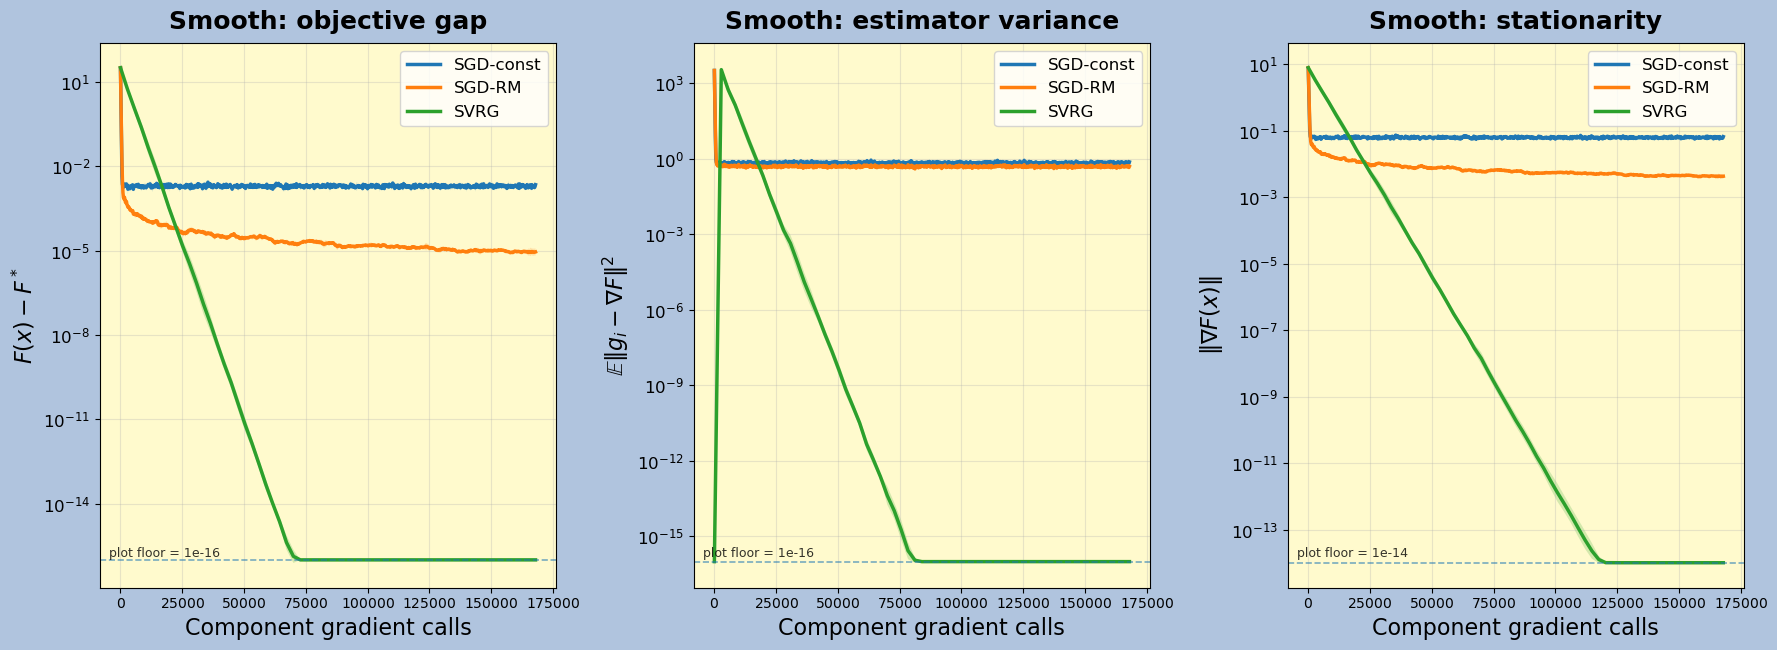

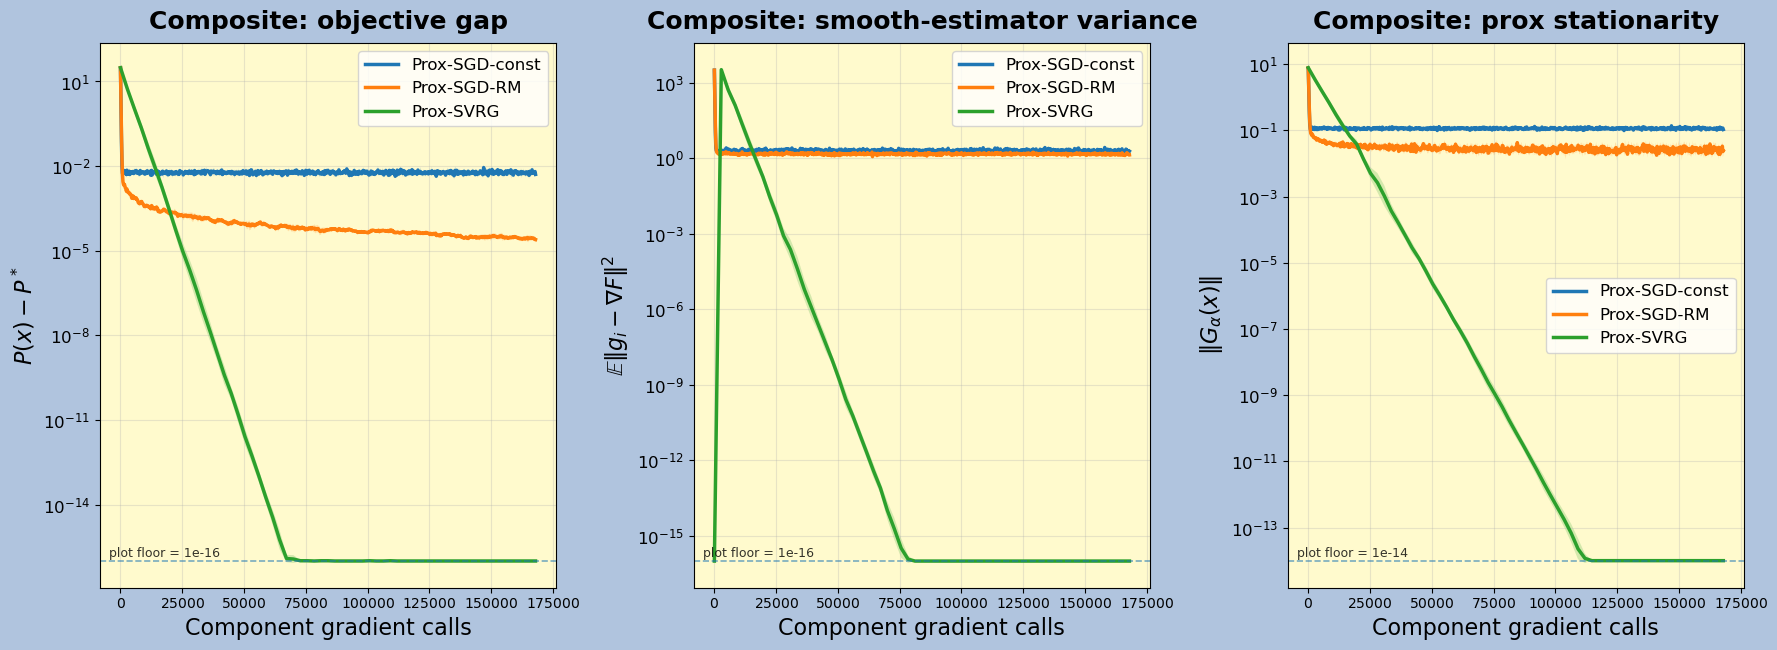


Generating summary plots...

Generating summary plots...


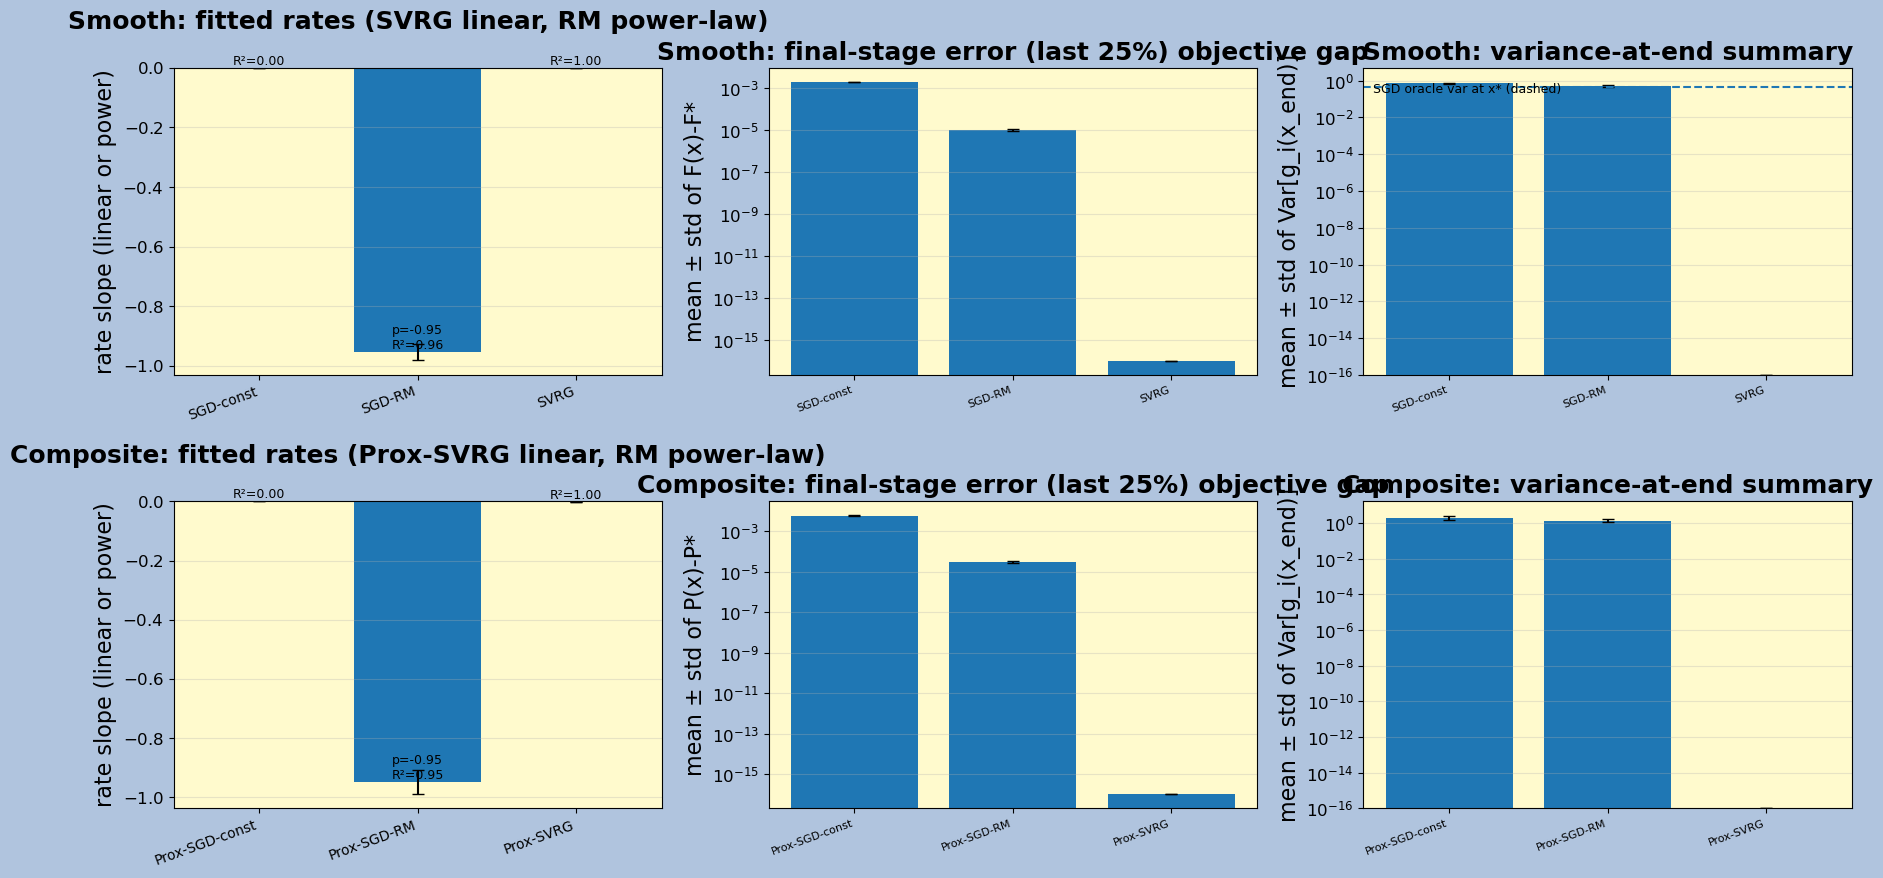

In [ ]:
plt.rcParams.update({
    'xtick.labelsize': 10,    # x-axis tick labels
    'ytick.labelsize': 12,    # y-axis tick labels
    'axes.formatter.use_mathtext': True,
})

if __name__ == "__main__":
    # Epxeriment Configurations
    cfg = {
        "n": 2000, "d": 50, # synthetic data matrix dimensions 
        "noise_std": 0.1,   # std of the gaussian noise
        "mu": 1e-4, # ridge regularisation strength 
        "lam": 2e-2,    # l1 stength

        "seeds": [0, 1, 2, 3, 4],   

        "svrg_epochs": 60,  # number of outer loops (epochs)
        "svrg_m": 400,  # number of inner stochastic loops

        "log_every_sgd": 200,   # we log metric after this many iterations 
        "log_every_svrg": 1,    # for svrg we log once per epoch
        "variance_sample_size": 120,    # how many samples we use to estimate variance 

        # summaries
        "tail_frac": 0.25,  # percentage of data used to estimate floor 
        "rate_y_hi_smooth": 1e-2,   
        "rate_y_lo_smooth": 1e-10,
        "rate_y_hi_comp": 1e-2,
        "rate_y_lo_comp": 1e-10,
    }

    # Setup
    A, b, _, mu = make_toy_least_squares(cfg["n"], cfg["d"], cfg["noise_std"], cfg["mu"], 42)
    A, b = standardise_problem(A, b)
    L, m_sc = estimate_L_and_m(A, mu)   # lipschits constant and strong convexity number 
    kappa = L / max(m_sc, 1e-16)    # condition number 

    # svrg gradient call counting (this defines the budget)
    total_calls = cfg["svrg_epochs"] * (cfg["n"] + 2 * cfg["svrg_m"])
    sgd_steps = total_calls

    alpha_sgd = 0.015 / L
    alpha_vr  = 0.01 / L

    # Robbins–Monro schedule for SGD / Prox-SGD (RM-compliant)
    rm_b = 1000  # you can tune, but 1000 is fine for now
    alpha_fn_sgd = rm_stepsize_schedule(alpha_sgd, b=rm_b)

    # recording and printing experimental parameters
    print("=" * 80)
    print(f"SETUP: n={cfg['n']}, d={cfg['d']}, μ={mu:.2e}, L={L:.6f}, κ={kappa:.3e}")
    print(f"Steps: α_SGD={alpha_sgd:.6e} (αL={alpha_sgd*L:.4f}), α_VR={alpha_vr:.6e} (αL={alpha_vr*L:.4f})")
    print(f"Budget: {sgd_steps} component-gradient calls")
    print("=" * 80)

    # eeference solutions
    x_smooth = solve_smooth_star(A, b, mu)
    x_comp, resid = solve_composite_star(A, b, mu, cfg["lam"])
    F_star = F_value(A, b, x_smooth, mu)
    P_star = P_value(A, b, x_comp, mu, cfg["lam"])

    print(f"F*={F_star:.8e}, P*={P_star:.8e}")
    print(f"Sparsity (<1e-6): {np.sum(np.abs(x_comp) < 1e-6)}/{cfg['d']}, residual={resid:.2e}")

    # oracle variance at optimum for SGD (smooth)
    rng0 = np.random.default_rng(123)
    var_idx_star = rng0.integers(0, A.shape[0], size=min(500, A.shape[0]))
    var_sgd_at_star = estimate_variance(A, b, x_smooth, mu, var_idx_star, estimator="sgd")
    print(f"Estimated Var[∇f_i(x*)] (SGD oracle) ≈ {var_sgd_at_star:.3e}")

    x0 = np.zeros(cfg["d"], dtype=np.float64)

    # Run experiments
    print("\nRunning experiments...")
    logs_sgd_const = [
    run_sgd(A, b, x0, sgd_steps, alpha_sgd, mu, x_smooth, F_star,
            seed=s, log_every=cfg["log_every_sgd"],
            variance_sample_size=cfg["variance_sample_size"],
            alpha_fn=None)[1]
    for s in cfg["seeds"]
]
    logs_sgd_rm = [
        run_sgd(A, b, x0, sgd_steps, alpha_sgd, mu, x_smooth, F_star,
                seed=s, log_every=cfg["log_every_sgd"],
                variance_sample_size=cfg["variance_sample_size"],
                alpha_fn=alpha_fn_sgd)[1]
        for s in cfg["seeds"]
    ]


    logs_svrg = [run_svrg(A, b, x0, cfg["svrg_epochs"], cfg["svrg_m"], alpha_vr, mu, x_smooth, F_star,
                         seed=s, log_every=cfg["log_every_svrg"], variance_sample_size=cfg["variance_sample_size"])[1]
                 for s in cfg["seeds"]]

    logs_psgd_const = [
    run_prox_sgd(A, b, x0, sgd_steps, alpha_sgd, mu, cfg["lam"], x_comp, P_star,
                 seed=s, log_every=cfg["log_every_sgd"],
                 variance_sample_size=cfg["variance_sample_size"],
                 alpha_fn=None)[1]
    for s in cfg["seeds"]
]

    logs_psgd_rm = [
        run_prox_sgd(A, b, x0, sgd_steps, alpha_sgd, mu, cfg["lam"], x_comp, P_star,
                    seed=s, log_every=cfg["log_every_sgd"],
                    variance_sample_size=cfg["variance_sample_size"],
                    alpha_fn=alpha_fn_sgd)[1]
        for s in cfg["seeds"]
]
    logs_psvrg = [run_prox_svrg(A, b, x0, cfg["svrg_epochs"], cfg["svrg_m"], alpha_vr, mu, cfg["lam"], x_comp, P_star,
                               seed=s, log_every=cfg["log_every_svrg"], variance_sample_size=cfg["variance_sample_size"])[1]
                  for s in cfg["seeds"]]

    # Save logs for reproducibility
    dump_logs_json("logs_sgd_const.json", logs_sgd_const)
    dump_logs_json("logs_sgd_rm.json", logs_sgd_rm)
    dump_logs_json("logs_svrg.json", logs_svrg)
    dump_logs_json("logs_psgd_conts.json", logs_psgd_const)
    dump_logs_json("logs_psgd_rm.json", logs_psgd_rm)
    dump_logs_json("logs_psvrg.json", logs_psvrg)

    # =============================================================================
    # MECHANISM PLOTS
    # =============================================================================
    print("\nGenerating mechanism plots (split smooth/composite)...")

    FIG_FACECOLOR = "lightsteelblue"
    AX_FACECOLOR  = "lemonchiffon"

    def style_axes(ax):
        ax.set_facecolor(AX_FACECOLOR)
        ax.grid(True, which="both", alpha=0.3)

    def add_floor_line(ax, y_floor):
        ax.axhline(y_floor, linestyle="--", linewidth=1.2, alpha=0.6)
        ax.text(0.02, 0.05, f"plot floor = {y_floor:.0e}",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=9, alpha=0.8
        )

    # ---------- Smooth mechanism figure (1x3) ----------
    fig_mech_s, axes_s = plt.subplots(1, 3, figsize=(18, 7))
    fig_mech_s.patch.set_facecolor(FIG_FACECOLOR)

    smooth_panels = [
        (axes_s[0], "obj_gap",      r"$F(x)-F^*$",                       "Smooth: objective gap"),
        (axes_s[1], "variance",     r"$\mathbb{E}\|g_i-\nabla F\|^2$",   "Smooth: estimator variance"),
        (axes_s[2], "stationarity", r"$\|\nabla F(x)\|$",                "Smooth: stationarity"),
    ]

    for ax, ykey, ylabel, title in smooth_panels:
        y_floor = floor_for(ykey)

        for name, logs in [("SGD-const", logs_sgd_const), ("SGD-RM",    logs_sgd_rm), ("SVRG",      logs_svrg)]:
            xs, ym, ylo, yhi = aggregate_log_curves(logs, ykey=ykey, y_floor=y_floor)
            if len(xs) > 0:
                ax.plot(xs, ym, label=name, linewidth=2.5)
                ax.fill_between(xs, ylo, yhi, alpha=0.2)

        add_floor_line(ax, y_floor)
        ax.set_yscale("log")
        ax.set_xlabel("Component gradient calls", fontsize = 16)
        ax.set_ylabel(ylabel, fontsize = 16)
        ax.set_title(title, fontweight="bold", pad=10)
        style_axes(ax)
        ax.legend()

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("mechanism_plots_smooth.png", dpi=300, bbox_inches="tight", facecolor=fig_mech_s.get_facecolor())
    plt.show()

    # ---------- Composite mechanism figure (1x3) ----------
    fig_mech_c, axes_c = plt.subplots(1, 3, figsize=(18, 7))
    fig_mech_c.patch.set_facecolor(FIG_FACECOLOR)

    comp_panels = [
        (axes_c[0], "obj_gap",      r"$P(x)-P^*$",                       "Composite: objective gap"),
        (axes_c[1], "variance",     r"$\mathbb{E}\|g_i-\nabla F\|^2$",   "Composite: smooth-estimator variance"),
        (axes_c[2], "stationarity", r"$\|G_\alpha(x)\|$",                "Composite: prox stationarity"),
    ]

    for ax, ykey, ylabel, title in comp_panels:
        y_floor = floor_for(ykey)

        for name, logs in [("Prox-SGD-const", logs_psgd_const), ("Prox-SGD-RM",    logs_psgd_rm), ("Prox-SVRG",      logs_psvrg)]:
            xs, ym, ylo, yhi = aggregate_log_curves(logs, ykey=ykey, y_floor=y_floor)
            if len(xs) > 0:
                ax.plot(xs, ym, label=name, linewidth=2.5)
                ax.fill_between(xs, ylo, yhi, alpha=0.2)

        add_floor_line(ax, y_floor)
        ax.set_yscale("log")
        ax.set_xlabel("Component gradient calls", fontsize = 16)
        ax.set_ylabel(ylabel, fontsize = 16)
        ax.set_title(title, fontweight="bold", pad=10)
        style_axes(ax)
        ax.legend()

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("mechanism_plots_composite.png", dpi=300, bbox_inches="tight", facecolor=fig_mech_c.get_facecolor())
    plt.show()

    # =============================================================================
    # SUMMARY PLOTS (rates, noise floors, variance-at-end)
    # =============================================================================
    print("\nGenerating summary plots...")

    def summarise_method(all_logs, label, is_smooth=True, fit_kind="linear"):
        slopes, r2s, nfits = [], [], []

        for logs in all_logs:
            if fit_kind == "linear":
                slope, r2, nfit = fit_linear_rate(
                    logs, ykey="obj_gap",
                    y_hi=cfg["rate_y_hi_smooth"] if is_smooth else cfg["rate_y_hi_comp"],
                    y_lo=cfg["rate_y_lo_smooth"] if is_smooth else cfg["rate_y_lo_comp"],
                )
            elif fit_kind == "power":
                slope, r2, nfit = fit_power_rate(
                    logs, ykey="obj_gap",
                    y_hi=cfg["rate_y_hi_smooth"] if is_smooth else cfg["rate_y_hi_comp"],
                    y_lo=cfg["rate_y_lo_smooth"] if is_smooth else cfg["rate_y_lo_comp"],
                )
            else:
                slope, r2, nfit = np.nan, np.nan, 0

            slopes.append(slope)
            r2s.append(r2)
            nfits.append(nfit)

        gaps, dists, vars_end = [], [], []
        for logs in all_logs:
            gm, _, _ = tail_stats(logs, ykey="obj_gap", tail_frac=cfg["tail_frac"])
            dm, _, _ = tail_stats(logs, ykey="dist2",  tail_frac=cfg["tail_frac"])
            gaps.append(gm)
            dists.append(dm)

            v = np.nan
            for r in reversed(logs):
                vv = r.get("variance", np.nan)
                if (not r.get("diverged", False)) and np.isfinite(vv):
                    v = float(vv)
                    break
            vars_end.append(v)

        valid_fit = np.array(nfits) >= 8

        return {
            "label": label,
            "fit_kind": fit_kind,
            "fit_frac": float(np.mean(valid_fit)) if len(valid_fit) else 0.0,
            "nfit_mean": float(np.mean([n for n in nfits if n >= 8])) if np.any(valid_fit) else 0.0,
            "slope_mean": float(np.nanmean(slopes)),
            "slope_std": float(np.nanstd(slopes)),
            "r2_mean": float(np.nanmean(r2s)),
            "gap_tail_mean": float(np.nanmean(gaps)),
            "gap_tail_std": float(np.nanstd(gaps)),
            "dist_tail_mean": float(np.nanmean(dists)),
            "dist_tail_std": float(np.nanstd(dists)),
            "var_end_mean": float(np.nanmean(vars_end)),
            "var_end_std": float(np.nanstd(vars_end)),
        }

    smooth_summaries = [
        summarise_method(logs_sgd_const, "SGD-const", is_smooth=True, fit_kind="linear"),
        summarise_method(logs_sgd_rm,    "SGD-RM",    is_smooth=True, fit_kind="power"),
        summarise_method(logs_svrg,      "SVRG",      is_smooth=True, fit_kind="linear"),
    ]

    comp_summaries = [
        summarise_method(logs_psgd_const, "Prox-SGD-const", is_smooth=False, fit_kind="linear"),
        summarise_method(logs_psgd_rm,    "Prox-SGD-RM",    is_smooth=False, fit_kind="power"),
        summarise_method(logs_psvrg,      "Prox-SVRG",      is_smooth=False, fit_kind="linear"),
    ]


    print("\nGenerating summary plots...")
    def apply_fig_style(fig):
        """Aesthetics-only: set figure background."""
        fig.patch.set_facecolor(FIG_FACECOLOR)

    def apply_ax_style(ax, grid_axis="both", which="both", grid_alpha=0.3):
        """Aesthetics-only: set axes background + grid."""
        ax.set_facecolor(AX_FACECOLOR)
        ax.grid(True, which=which, axis=grid_axis, alpha=grid_alpha)

    def apply_axes_style(axes, grid_axis="both", which="both", grid_alpha=0.3):
        """Apply style to an array/list of axes."""
        for ax in np.ravel(axes):
            apply_ax_style(ax, grid_axis=grid_axis, which=which, grid_alpha=grid_alpha)


    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 9))

    apply_fig_style(fig2)
    apply_axes_style(axes2, grid_axis="y", which="major", grid_alpha=0.3)


    def rate_panel(ax, summaries, title, na_labels=set()):
        labels = [s["label"] for s in summaries]
        x = np.arange(len(labels))

        means = np.array([s["slope_mean"] for s in summaries], dtype=float)
        stds  = np.array([s["slope_std"]  for s in summaries], dtype=float)
        kinds = [s.get("fit_kind", "linear") for s in summaries]

        is_na = np.array([lab in na_labels for lab in labels])

        # bars
        ax.bar(x[~is_na], means[~is_na], yerr=stds[~is_na], capsize=4)
        ax.bar(x[is_na], np.zeros(np.sum(is_na)))

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_title(title, fontweight="bold", pad=28)
        ax.grid(True, axis="y", alpha=0.3)

        # y-label that matches the fit kind (if mixed, keep generic)
        uniq_kinds = sorted(set(kinds))
        if uniq_kinds == ["linear"]:
            ax.set_ylabel("slope of log(gap) vs calls")
        elif uniq_kinds == ["power"]:
            ax.set_ylabel("power slope p in gap ~ calls^p")
        else:
            ax.set_ylabel("rate slope (linear or power)")

        for i, s in enumerate(summaries):
            if labels[i] in na_labels:
                ax.text(i, 0.0, "N/A", ha="center", va="bottom", fontsize=9)
            else:
                kind = s.get("fit_kind", "linear")
                if kind == "linear":
                    ax.text(i, means[i], f"R²={s['r2_mean']:.2f}", ha="center", va="bottom", fontsize=9)
                else:
                    # power fit annotation
                    ax.text(i, means[i], f"p={means[i]:.2f}\nR²={s['r2_mean']:.2f}", ha="center", va="bottom", fontsize=9)

    rate_panel(
    axes2[0, 0],
    smooth_summaries,
    "Smooth: fitted rates (SVRG linear, RM power-law)",
    na_labels=set()  # you can leave empty now
)

    rate_panel(
        axes2[1, 0],
        comp_summaries,
        "Composite: fitted rates (Prox-SVRG linear, RM power-law)",
        na_labels=set()
    )

    def bar_with_err(ax, summaries, key_mean, key_std, title, ylabel,
                 annotate_r2=False, logy=False, clip_floor=None, annotate_na=False):
        labels = [s["label"] for s in summaries]
        means = np.array([s.get(key_mean, np.nan) for s in summaries], dtype=float)
        stds  = np.array([s.get(key_std,  np.nan) for s in summaries], dtype=float)

        # Handle NaNs
        is_bad = ~np.isfinite(means)
        means_plot = means.copy()
        stds_plot = stds.copy()

        # If log scale: cannot plot 0/NaN -> clip
        if logy:
            if clip_floor is None:
                clip_floor = 1e-16
            means_plot[is_bad] = clip_floor
            means_plot = np.maximum(means_plot, clip_floor)
            stds_plot[~np.isfinite(stds_plot)] = 0.0
        else:
            means_plot[is_bad] = 0.0
            stds_plot[~np.isfinite(stds_plot)] = 0.0

        x = np.arange(len(labels))
        ax.bar(x, means_plot, yerr=stds_plot, capsize=4)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)

        if logy:
            ax.set_yscale("log")

        if annotate_r2:
            for i, s in enumerate(summaries):
                ax.text(i, means_plot[i], f"R²={s['r2_mean']:.2f}", ha="center", va="bottom", fontsize=9)

        if annotate_na:
            for i, bad in enumerate(is_bad):
                if bad:
                    ax.text(i, means_plot[i], "N/A", ha="center", va="bottom", fontsize=9)

    bar_with_err(
        axes2[0, 1], smooth_summaries,
        "gap_tail_mean", "gap_tail_std",
        f"Smooth: final-stage error (last {int(cfg['tail_frac']*100)}%) objective gap",
        "mean ± std of F(x)-F*",
        logy=True
    )
    bar_with_err(
        axes2[1, 1], comp_summaries,
        "gap_tail_mean", "gap_tail_std",
        f"Composite: final-stage error (last {int(cfg['tail_frac']*100)}%) objective gap",
        "mean ± std of P(x)-P*",
        logy=True
    )

    bar_with_err(
        axes2[0, 2], smooth_summaries,
        "var_end_mean", "var_end_std",
        "Smooth: variance-at-end summary",
        "mean ± std of Var[g_i(x_end)]",
        logy=True, clip_floor=VAR_FLOOR
    )
    axes2[0, 2].axhline(var_sgd_at_star, linestyle="--", linewidth=1.5)
    axes2[0, 2].text(0.02, 0.95, "SGD oracle var at x* (dashed)",
                    transform=axes2[0, 2].transAxes, ha="left", va="top", fontsize=9)

    bar_with_err(
        axes2[1, 2], comp_summaries,
        "var_end_mean", "var_end_std",
        "Composite: variance-at-end summary",
        "mean ± std of Var[g_i(x_end)]",
        logy=True, clip_floor=VAR_FLOOR
    )

    axes2[0, 2].set_ylim(bottom=VAR_FLOOR)
    axes2[1, 2].set_ylim(bottom=VAR_FLOOR)

    plt.tight_layout()
    plt.savefig("summary_plots.png", dpi=300, bbox_inches="tight", facecolor=fig2.get_facecolor())
    plt.show()